In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sonar.all-data",header=None)
df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
108,0.0599,0.0474,0.0498,0.0387,0.1026,0.0773,0.0853,0.0447,0.1094,0.0351,...,0.0013,0.0005,0.0227,0.0209,0.0081,0.0117,0.0114,0.0112,0.0100,M
30,0.0240,0.0218,0.0324,0.0569,0.0330,0.0513,0.0897,0.0713,0.0569,0.0389,...,0.0162,0.0146,0.0093,0.0112,0.0094,0.0054,0.0019,0.0066,0.0023,R
141,0.0707,0.1252,0.1447,0.1644,0.1693,0.0844,0.0715,0.0947,0.1583,0.1247,...,0.0156,0.0197,0.0135,0.0127,0.0138,0.0133,0.0131,0.0154,0.0218,M
54,0.0132,0.0080,0.0188,0.0141,0.0436,0.0668,0.0609,0.0131,0.0899,0.0922,...,0.0044,0.0028,0.0021,0.0022,0.0048,0.0138,0.0140,0.0028,0.0064,R


In [3]:
df.shape

(208, 61)

In [4]:
len(df.columns)

61

In [5]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [6]:
df[60] = df[60].map({"R":1,"M":0})

In [7]:
X = df.drop(60,axis=1)
y = df[60]

In [8]:
type(y)

pandas.core.series.Series

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [10]:
type(X_train.values)

numpy.ndarray

In [11]:
X_train_tensor = torch.tensor(X_train.values,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.long)

In [12]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

### Simple Neural Network

In [14]:
for a,b in train_loader:
    print (a,b)
    break

tensor([[6.3500e-02, 7.0900e-02, 4.5300e-02, 3.3300e-02, 1.8500e-02, 1.2600e-01,
         1.0150e-01, 1.9180e-01, 3.3620e-01, 3.9000e-01, 4.6740e-01, 5.6320e-01,
         5.5060e-01, 4.3430e-01, 3.0520e-01, 3.4920e-01, 3.9750e-01, 3.8750e-01,
         5.2800e-01, 7.1980e-01, 7.7020e-01, 8.5620e-01, 8.6880e-01, 9.2360e-01,
         1.0000e+00, 9.6620e-01, 9.8220e-01, 7.3600e-01, 4.1580e-01, 2.9180e-01,
         3.2800e-01, 3.6900e-01, 3.4500e-01, 2.8630e-01, 8.6400e-02, 3.7240e-01,
         4.6490e-01, 3.4880e-01, 1.8170e-01, 1.1420e-01, 1.2200e-01, 2.6210e-01,
         4.4610e-01, 4.7260e-01, 3.2630e-01, 1.4230e-01, 3.9000e-02, 4.0600e-02,
         3.1100e-02, 8.6000e-03, 1.5400e-02, 4.8000e-03, 2.5000e-03, 8.7000e-03,
         7.2000e-03, 9.5000e-03, 8.6000e-03, 8.5000e-03, 4.0000e-03, 5.1000e-03],
        [2.0100e-02, 2.6000e-03, 1.3800e-02, 6.2000e-03, 1.3300e-02, 1.5100e-02,
         5.4100e-02, 2.1000e-02, 5.0500e-02, 1.0970e-01, 8.4100e-02, 9.4200e-02,
         1.2040e-01, 4.2000

In [15]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )
    def forward(self,x):
        return self.network(x)

#### Model Training

In [16]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [17]:
def train_test_model(model,criterion,optimizer,train_loader,test_loader,epochs=20):
    model.train()
    epochs = 20
    train_losses,val_losses,val_accuracies = [],[],[]
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for inputs,labels in train_loader:
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions,labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_batch_loss = epoch_loss/len(train_loader)
        train_losses.append(avg_batch_loss)
    
        model.eval()
        with torch.no_grad():
            running_val_loss = 0.0
            true_lables,all_pred = [],[]
            for inputs,labels in test_loader:
                outputs = model(inputs)
                val_loss = criterion(outputs,labels)
                running_val_loss += val_loss.item()
                _,pred = torch.max(outputs,1)
                true_lables.extend(labels.cpu().numpy())
                all_pred.extend(pred.cpu().numpy())
            val_losses.append(running_val_loss/len(test_loader))
            val_accuracy = accuracy_score(true_lables,all_pred)
            val_accuracies.append(val_accuracy)
        print(f"Epoch: {epoch+1}/{epochs}, Training_Loss: { train_losses[-1]: .4f}, val_loss: {val_losses[-1] :.4f}, val_accuracy: {val_accuracies[-1]:.4f}")
    return train_losses,val_losses,val_accuracies

#### NN without dropout layer

In [18]:
train_losses,val_losses,val_accuracies =  train_test_model(model,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6866, val_loss: 0.6646, val_accuracy: 0.5192
Epoch: 2/20, Training_Loss:  0.6728, val_loss: 0.6477, val_accuracy: 0.5962
Epoch: 3/20, Training_Loss:  0.6561, val_loss: 0.6284, val_accuracy: 0.6731
Epoch: 4/20, Training_Loss:  0.6273, val_loss: 0.6013, val_accuracy: 0.6538
Epoch: 5/20, Training_Loss:  0.5930, val_loss: 0.5856, val_accuracy: 0.7500
Epoch: 6/20, Training_Loss:  0.5545, val_loss: 0.5350, val_accuracy: 0.7500
Epoch: 7/20, Training_Loss:  0.5062, val_loss: 0.5359, val_accuracy: 0.7692
Epoch: 8/20, Training_Loss:  0.4637, val_loss: 0.5159, val_accuracy: 0.7500
Epoch: 9/20, Training_Loss:  0.4326, val_loss: 0.4893, val_accuracy: 0.7692
Epoch: 10/20, Training_Loss:  0.4235, val_loss: 0.5926, val_accuracy: 0.7500
Epoch: 11/20, Training_Loss:  0.4092, val_loss: 0.4656, val_accuracy: 0.7308
Epoch: 12/20, Training_Loss:  0.3696, val_loss: 0.4867, val_accuracy: 0.7308
Epoch: 13/20, Training_Loss:  0.3569, val_loss: 0.4513, val_accuracy: 0.7500
Epoch: 1

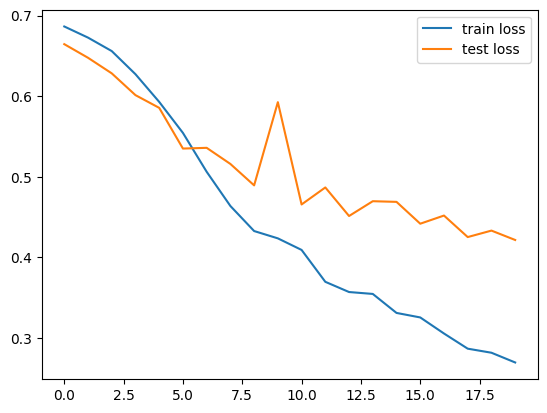

In [19]:
plt.plot(train_losses,label="train loss")
plt.plot(val_losses,label="test loss")
plt.legend()
plt.show()

### model with dropout layer

In [20]:
class nn_with_dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60,128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64,2),
        )
    def forward(self,x):
        return self.network(x)

In [21]:
model_with_dropout = nn_with_dropout()
optimizer = optim.Adam(model_with_dropout.parameters(),lr=0.001)

In [22]:

train_loss_dropout,val_loss_dropout,val_acc_dropout = train_test_model(model_with_dropout,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6901, val_loss: 0.6769, val_accuracy: 0.5192
Epoch: 2/20, Training_Loss:  0.6977, val_loss: 0.6770, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6776, val_loss: 0.6660, val_accuracy: 0.5192
Epoch: 4/20, Training_Loss:  0.6862, val_loss: 0.6593, val_accuracy: 0.5192
Epoch: 5/20, Training_Loss:  0.6615, val_loss: 0.6601, val_accuracy: 0.5192
Epoch: 6/20, Training_Loss:  0.6681, val_loss: 0.6466, val_accuracy: 0.5577
Epoch: 7/20, Training_Loss:  0.6559, val_loss: 0.6362, val_accuracy: 0.5962
Epoch: 8/20, Training_Loss:  0.6540, val_loss: 0.6193, val_accuracy: 0.5962
Epoch: 9/20, Training_Loss:  0.6363, val_loss: 0.6089, val_accuracy: 0.6923
Epoch: 10/20, Training_Loss:  0.6221, val_loss: 0.6028, val_accuracy: 0.7692
Epoch: 11/20, Training_Loss:  0.5895, val_loss: 0.5779, val_accuracy: 0.6538
Epoch: 12/20, Training_Loss:  0.5709, val_loss: 0.5658, val_accuracy: 0.7115
Epoch: 13/20, Training_Loss:  0.5803, val_loss: 0.5556, val_accuracy: 0.7115
Epoch: 1

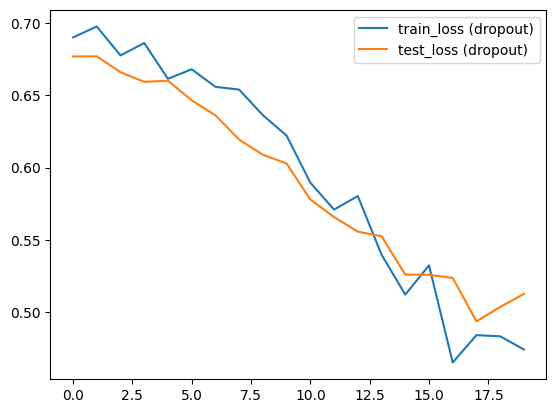

In [23]:
plt.plot(train_loss_dropout,label="train_loss (dropout)")
plt.plot(val_loss_dropout,label="test_loss (dropout)")
plt.legend()
plt.show()


#### Trainig using L2 Regularization

In [24]:
model_with_l2 = SimpleNN()
optimizer = optim.Adam(model_with_l2.parameters(),lr=0.001,weight_decay=0.03)

train_loss_l2,val_loss_l2,val_acc_l2 = train_test_model(model_with_l2,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6921, val_loss: 0.6810, val_accuracy: 0.5192
Epoch: 2/20, Training_Loss:  0.6888, val_loss: 0.6764, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6873, val_loss: 0.6761, val_accuracy: 0.5192
Epoch: 4/20, Training_Loss:  0.6866, val_loss: 0.6743, val_accuracy: 0.5192
Epoch: 5/20, Training_Loss:  0.6851, val_loss: 0.6732, val_accuracy: 0.5192
Epoch: 6/20, Training_Loss:  0.6850, val_loss: 0.6746, val_accuracy: 0.5192
Epoch: 7/20, Training_Loss:  0.6842, val_loss: 0.6699, val_accuracy: 0.5192
Epoch: 8/20, Training_Loss:  0.6833, val_loss: 0.6718, val_accuracy: 0.5192
Epoch: 9/20, Training_Loss:  0.6809, val_loss: 0.6668, val_accuracy: 0.5192
Epoch: 10/20, Training_Loss:  0.6788, val_loss: 0.6648, val_accuracy: 0.5192
Epoch: 11/20, Training_Loss:  0.6788, val_loss: 0.6613, val_accuracy: 0.5192
Epoch: 12/20, Training_Loss:  0.6753, val_loss: 0.6598, val_accuracy: 0.5192
Epoch: 13/20, Training_Loss:  0.6704, val_loss: 0.6553, val_accuracy: 0.5192
Epoch: 1

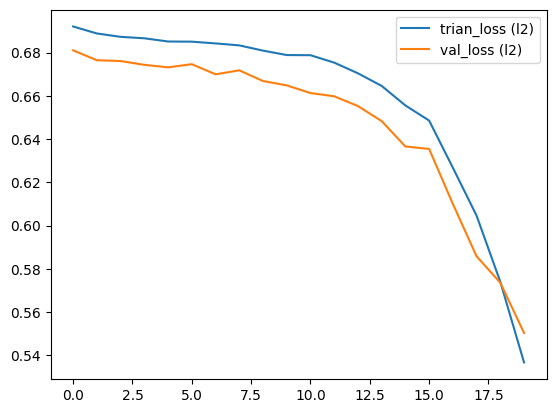

In [25]:
plt.plot(train_loss_l2,label="trian_loss (l2)")
plt.plot(val_loss_l2,label="val_loss (l2)")
plt.legend()
plt.show()

### Early Stopping

In [26]:
def train_model_early_stop(model,criterion,optimizer,train_loader,test_loader,epochs=20):
    patience = 3
    best_acc = 0
    counter = 0
    
    model.train()
    train_losses,val_losses,val_accuracies = [],[],[]
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for inputs,labels in train_loader:
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions,labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_batch_loss = epoch_loss/len(train_loader)
        train_losses.append(avg_batch_loss)
    
        model.eval()
        running_val_loss = 0.0
        true_lables,all_pred = [],[]
        with torch.no_grad():
            for inputs,labels in test_loader:
                outputs = model(inputs)
                val_loss = criterion(outputs,labels)
                running_val_loss += val_loss.item()
                _,pred = torch.max(outputs,1)
                true_lables.extend(labels.cpu().numpy())
                all_pred.extend(pred.cpu().numpy())
        val_losses.append(running_val_loss/len(test_loader))
        val_accuracy = accuracy_score(true_lables,all_pred)
        val_accuracies.append(val_accuracy)
        print(f"Epoch: {epoch+1}/{epochs}, Training_Loss: { train_losses[-1]: .4f}, val_loss: {val_losses[-1] :.4f}, val_accuracy: {val_accuracies[-1]:.4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            counter = 0
            torch.save(model.state_dict(),"best_model.pt")
        else:
            counter +=1
            if counter>=patience:
                print(f"Early Stopping at epoch {epoch+1}")
                break
            
            
        
    return train_losses,val_losses,val_accuracies

In [27]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [28]:
train_losses_es,val_losses_es,val_accuracies_es =  train_model_early_stop(model,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6936, val_loss: 0.6764, val_accuracy: 0.5385
Epoch: 2/20, Training_Loss:  0.6795, val_loss: 0.6561, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6632, val_loss: 0.6394, val_accuracy: 0.6538
Epoch: 4/20, Training_Loss:  0.6413, val_loss: 0.6184, val_accuracy: 0.7115
Epoch: 5/20, Training_Loss:  0.6203, val_loss: 0.5832, val_accuracy: 0.7115
Epoch: 6/20, Training_Loss:  0.5880, val_loss: 0.5813, val_accuracy: 0.8462
Epoch: 7/20, Training_Loss:  0.5524, val_loss: 0.5397, val_accuracy: 0.6731
Epoch: 8/20, Training_Loss:  0.5168, val_loss: 0.5294, val_accuracy: 0.7692
Epoch: 9/20, Training_Loss:  0.4886, val_loss: 0.5170, val_accuracy: 0.7885
Early Stopping at epoch 9


In [29]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [30]:
model.eval()
true_lables,all_pred = [],[]
with torch.no_grad():
    for inputs,labels in test_loader:
        outputs = model(inputs)
        val_loss = criterion(outputs,labels)
        _,pred = torch.max(outputs,1)
        true_lables.extend(labels.cpu().numpy())
        all_pred.extend(pred.cpu().numpy())
val_accuracy = accuracy_score(true_lables,all_pred)
val_accuracy

0.8461538461538461

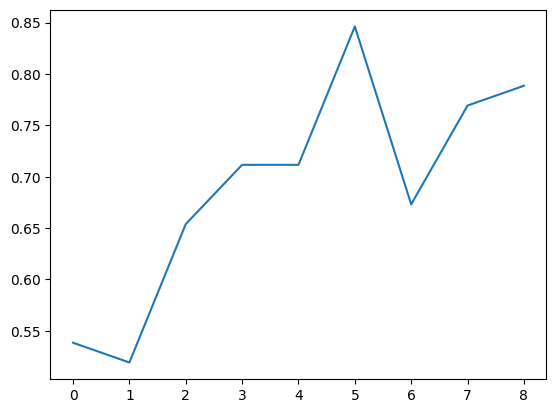

In [31]:
plt.plot(val_accuracies_es)